# Evaluation of results from a model

Load any trained model, score, evaluate and visualise results on the three-way split (70 / 15 / 15).

Works with both model types - `score_windows()` dispatches automatically:
- **sklearn PCA**  → `models/pca.pkl`
- **Keras AE**     → `models/lstm_ae.keras` / `models/cnn_ae.keras`

---
## 1. Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys, json, pickle, time
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sentinel.ml_logic.data      import PROCESSED_DIR, MODELS_DIR, RAW_DIR
from sentinel.ml_logic.data      import find_anomaly_segments, load_target_channels
from sentinel.ml_logic.scorer    import score_windows, score_report, detrend_scores
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, event_f1, event_f2, esa_metric,
    event_detection_rate, row_precision_recall, compute_all_metrics,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.ml_logic.viz        import plot_confusion_and_channel_errors
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR, WINDOW_SIZE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# Channel names from data/raw/target_channels.csv (used for confusion/top-channel plot)
FEATURES = load_target_channels()
print(f'Ready — {len(FEATURES)} target channels loaded')


Ready — 58 target channels loaded


### Load data

In [3]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)
WIN    = cfg['window_size']
N_FEAT = cfg['n_features']

val_scaled         = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val              = np.load(PROCESSED_DIR / 'y_val.npy')
test_intern_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test_intern      = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'  val         : {val_scaled.shape}  | anom rows: {int(y_val.sum()):,}')
print(f'  test_intern : {test_intern_scaled.shape}  | anom rows: {int(y_test_intern.sum()):,}')

  val         : (2232277, 58)  | anom rows: 246,463
  test_intern : (2186220, 58)  | anom rows: 214,961


### Load Model

In [4]:
# ── Model selector ───────────────────────────────────────────────────────
# Auto-lists every model file in MODELS_DIR. Pick one by setting MODEL_PATH
# directly (by filename) OR by picking from the AVAILABLE list by index.

AVAILABLE = sorted(
    [p for p in MODELS_DIR.glob('*') if p.suffix in ('.pkl', '.keras') and p.name != 'scaler.pkl'],
    key=lambda p: p.stat().st_mtime,
)

# Inventory print — newest last, so the bottom of the list is usually what you want.
print(f'{len(AVAILABLE)} model file(s) in {MODELS_DIR}:')
for i, p in enumerate(AVAILABLE):
    size_mb = p.stat().st_size / 1e6
    mtime   = pd.Timestamp(p.stat().st_mtime, unit='s').strftime('%Y-%m-%d %H:%M')
    print(f'  [{i:2d}] {p.name:<50s} {size_mb:6.2f} MB   {mtime}')


4 model file(s) in /Users/helena.schulz.ext/code/alexfederolf/sentinel/models:
  [ 0] cnn_ae.keras                                         0.44 MB   2026-04-23 14:34
  [ 1] pca.pkl                                              0.91 MB   2026-04-23 14:34
  [ 2] lstm_ae.keras                                        4.89 MB   2026-04-23 15:02
  [ 3] pca_kaggle.pkl                                       0.42 MB   2026-04-24 00:58


In [5]:
# ─── Pick a model ────────────────────────────────────────────────────────
MODEL_PATH = MODELS_DIR / 'lstm_ae.keras'
# MODEL_PATH = MODELS_DIR / 'lstm_ae.keras'
# MODEL_PATH = MODELS_DIR / 'cnn_ae.keras'

In [6]:
# Dispatch by file extension: .pkl → sklearn/PCA,  .keras → Keras / TF model.
if MODEL_PATH.suffix == '.pkl':
    with open(MODEL_PATH, 'rb') as f:
        model = pickle.load(f)
    ncomp = getattr(model, 'n_components_', None)
    print(f'{MODEL_NAME} loaded' + (f' — {ncomp} components' if ncomp else ''))

elif MODEL_PATH.suffix == '.keras':
    import tensorflow as tf
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print(f'{MODEL_NAME} loaded — {model.count_params():,} params')

else:
    raise ValueError(f'Unsupported model suffix: {MODEL_PATH.suffix}')


NameError: name 'MODEL_NAME' is not defined

---
## 3 - Scoring window


In [ ]:
# ─── Scoring knobs ────────────────────────────────────────────────────────
# Turn these to change how the model is scored. Re-run this cell to apply.
#   TOPK           : None = mean over all channels (PCA default).
#                    k    = mean of k largest per-channel MSEs (LSTM/CNN default = 5).
#   USE_DETREND    : True subtracts a rolling baseline from the row scores.
#                    Useful when val→test shows regime drift (see NB 18/20).
#   DETREND_MODE   : 'median' kills mean-drift. 'zscore' also normalises variance.
#   DETREND_WINDOW : rolling-window size in ROWS. ~50k–200k for ESA-ADB.
TOPK           = None if 'pca' in MODEL_NAME.lower() else 5
USE_DETREND    = False
DETREND_MODE   = 'median'   # 'median' | 'zscore'
DETREND_WINDOW = 100_000

# ─── Score both splits once ──────────────────────────────────────────────
t0 = time.time()
rep_val  = score_report(model, val_scaled,         win=WIN, batch=256, topk=TOPK)
rep_test = score_report(model, test_intern_scaled, win=WIN, batch=256, topk=TOPK)
scores_val         = rep_val['row_scores']
scores_test_intern = rep_test['row_scores']

if USE_DETREND:
    scores_val         = detrend_scores(scores_val,         window=DETREND_WINDOW, mode=DETREND_MODE)
    scores_test_intern = detrend_scores(scores_test_intern, window=DETREND_WINDOW, mode=DETREND_MODE)
    print(f'scored + detrended ({DETREND_MODE}, window={DETREND_WINDOW:,}) in {time.time()-t0:.1f}s   (topk={TOPK})')
else:
    print(f'scored in {time.time()-t0:.1f}s   (topk={TOPK}, detrend=off)')

print(f'  val  - nominal mean: {scores_val[y_val==0].mean():.5f}  '
      f'anomaly mean: {scores_val[y_val==1].mean():.5f}')
print(f'  test - nominal mean: {scores_test_intern[y_test_intern==0].mean():.5f}  '
      f'anomaly mean: {scores_test_intern[y_test_intern==1].mean():.5f}')


scored in 39.3s   (topk=5, detrend=off)
  val  - nominal mean: 0.82398  anomaly mean: 4.75926
  test - nominal mean: 4.38496  anomaly mean: 14.71433


#### 3b — What a window score actually measures *(zoom on one event)*

Pedagogical plot. Zooms into a short slice of `test_intern` around a real anomaly event and shows the three pieces that feed into the score:

1. **Top** — one channel: the true signal vs. the model's reconstruction. Red band = ground-truth anomaly.
2. **Middle** — per-row squared error averaged over all 58 channels. This is the raw "how surprised is the model" trace.
3. **Bottom** — the actual window scores that the threshold operates on. Each bar is `WIN=100` rows collapsed to one number. Red bars = windows that overlap a ground-truth anomaly. Black dashed line = current threshold.

Follow the bars up through the trace: the spike in the top two panels is *exactly* the bar that crosses the threshold line in the bottom panel. That's what "scoring window" means in one picture.

NameError: name 'THRESHOLD' is not defined

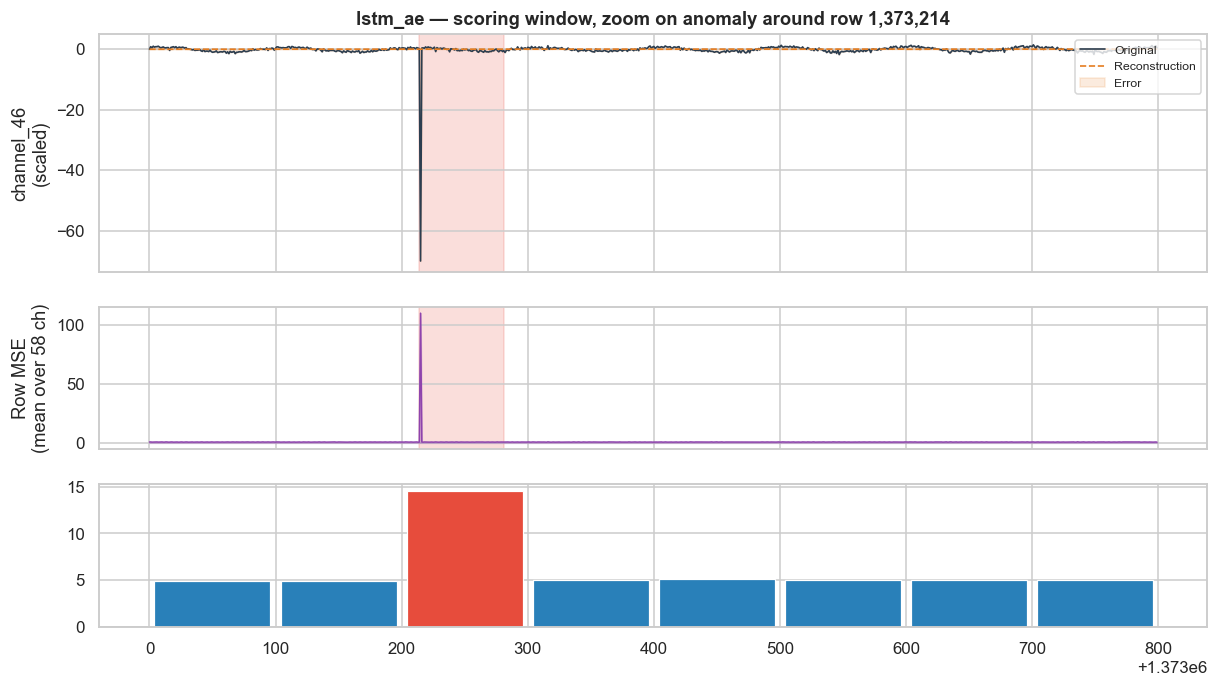

In [ ]:
# Pick an anomaly event from test_intern with ~5-8 windows of context.
segs = find_anomaly_segments(y_test_intern)
# prefer an event of ~2-5 windows — big enough to see, small enough to fit.
seg  = min(segs, key=lambda s: abs(s['length'] - 3 * WIN)) if segs else None
if seg is None:
    raise RuntimeError('no anomaly segments in test_intern — cannot build demo plot')

# Zoom: 2 windows of lead-in + event + windows to fill up to ~8 windows total.
N_WIN_ZOOM = 8
start_row  = max(0, (seg['start'] // WIN - 2) * WIN)
end_row    = min(len(y_test_intern), start_row + N_WIN_ZOOM * WIN)
n_win      = (end_row - start_row) // WIN
sl         = slice(start_row, start_row + n_win * WIN)

X           = test_intern_scaled[sl]                      # (n, 58)
y_true_zoom = y_test_intern[sl]
X_win       = X.reshape(n_win, WIN, -1)                   # (n_win, WIN, 58)

# Reconstruct this slice with the currently loaded model.
if MODEL_PATH.suffix == '.pkl':
    X_flat = X_win.reshape(n_win, WIN * X.shape[1])
    X_hat  = model.inverse_transform(model.transform(X_flat)).reshape(X_win.shape)
else:
    X_hat = np.asarray(model.predict(X_win, verbose=0), dtype=np.float32)

# Errors + window scores (mirrors score_report logic, TOPK-aware).
sq_err       = (X_win - X_hat) ** 2                       # (n_win, WIN, 58)
per_row_err  = sq_err.mean(axis=2).reshape(-1)            # (n,)     — mean over channels
per_win_chan = sq_err.mean(axis=1)                        # (n_win, 58)
if TOPK is None:
    win_scores_zoom = sq_err.mean(axis=(1, 2))
else:
    k = min(TOPK, per_win_chan.shape[1])
    top_vals = np.partition(per_win_chan, -k, axis=1)[:, -k:]
    win_scores_zoom = top_vals.mean(axis=1)

# Highlight channel: the one with highest mean error inside anomaly windows.
win_is_ano = y_true_zoom.reshape(n_win, WIN).any(axis=1)
if win_is_ano.any():
    ch = int(per_win_chan[win_is_ano].mean(axis=0).argmax())
else:
    ch = int(per_win_chan.mean(axis=0).argmax())
ch_name = FEATURES[ch] if ch < len(FEATURES) else f'ch {ch}'

# ── Plot: 3 stacked panels, shared x-axis ─────────────────────────────────
x_rows = np.arange(sl.start, sl.stop)
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2, 1.2]})

# Panel A — original vs reconstruction on the worst channel
axA = axes[0]
axA.plot(x_rows, X[:, ch],     color='#2c3e50', lw=1.1, label='Original')
axA.plot(x_rows, X_hat.reshape(-1, X.shape[1])[:, ch],
         color='#e67e22', lw=1.1, ls='--', label='Reconstruction')
axA.fill_between(x_rows, X[:, ch], X_hat.reshape(-1, X.shape[1])[:, ch],
                 color='#e67e22', alpha=0.15, label='Error')
# GT-anomaly band
for s in find_anomaly_segments(y_true_zoom):
    axA.axvspan(sl.start + s['start'], sl.start + s['end'] + 1,
                color=ANOMALY_COLOR, alpha=0.18, zorder=0)
axA.set_ylabel(f'{ch_name}\n(scaled)')
axA.set_title(f'{MODEL_NAME} — scoring window, zoom on anomaly around row {seg["start"]:,}',
              fontweight='bold')
axA.legend(loc='upper right', fontsize=8)

# Panel B — per-row mean squared error across all 58 channels
axB = axes[1]
axB.plot(x_rows, per_row_err, color='#8e44ad', lw=1.0)
axB.fill_between(x_rows, per_row_err, color='#8e44ad', alpha=0.25)
for s in find_anomaly_segments(y_true_zoom):
    axB.axvspan(sl.start + s['start'], sl.start + s['end'] + 1,
                color=ANOMALY_COLOR, alpha=0.18, zorder=0)
axB.set_ylabel('Row MSE\n(mean over 58 ch)')

# Panel C — window scores as bars, threshold overlaid
axC = axes[2]
win_centers = sl.start + (np.arange(n_win) + 0.5) * WIN
colors      = [ANOMALY_COLOR if a else NOMINAL_COLOR for a in win_is_ano]
axC.bar(win_centers, win_scores_zoom, width=WIN * 0.92,
        color=colors, edgecolor='white', linewidth=0.8)
axC.axhline(THRESHOLD, color='black', ls='--', lw=1.2,
            label=f'Threshold = {THRESHOLD:.5f}')
axC.set_ylabel(f'Window score\n(topk={TOPK})')
axC.set_xlabel('Row index (test_intern)')
axC.legend(loc='upper right', fontsize=8)

# Window boundaries on all panels
for ax in axes:
    for k in range(n_win + 1):
        ax.axvline(sl.start + k * WIN, color='#bdc3c7', lw=0.6, alpha=0.7, zorder=0)

fig.tight_layout(); plt.show()

print(f'channel highlighted : {ch_name}   (highest MSE inside anomaly window)')
print(f'windows shown       : {n_win}   ({WIN} rows each, total {n_win*WIN} rows)')
print(f'windows crossing thr: {int((win_scores_zoom > THRESHOLD).sum())} / {n_win}')


---
## 4 - Tune Threshold on Val

`tune_threshold` accepts any `metric_fn(y_true, y_pred) -> dict` (reads `f_score` by default) or a bare scalar via `score_key=None`. Primary run below uses **event F0.5** (precision-weighted, our headline tuning metric). The block after the sweep plot shows alternatives — event F1 (balanced), F2 (recall-weighted), ESA-corrected F0.5 (Kaggle-style, precision × TNR), and a custom row-level F1 — so you can pick the threshold that matches the downstream goal.

In [ ]:
# ─── Threshold knobs ──────────────────────────────────────────────────────
# MANUAL_THRESHOLD = None  → auto-tune on val with TUNE_METRIC.
# MANUAL_THRESHOLD = float → skip tuning and use this value directly.
# TUNE_METRIC      : any metric fn that returns a dict with key 'f_score',
#                    e.g. event_f05 (headline), event_f1, event_f2, esa_metric.
MANUAL_THRESHOLD = None
TUNE_METRIC      = event_f05 # !!! METRIC SELECTION HERE !!!-------------------

sweep = tune_threshold(scores_val, y_val, metric_fn=TUNE_METRIC)
if MANUAL_THRESHOLD is None:
    THRESHOLD = sweep['threshold']
    print(f'auto threshold : {THRESHOLD:.6f}  →  val {TUNE_METRIC.__name__} = {sweep["score"]:.4f}')
else:
    THRESHOLD = float(MANUAL_THRESHOLD)
    manual_score = TUNE_METRIC(y_val, (scores_val > THRESHOLD).astype(np.int8))['f_score']
    print(f'manual threshold: {THRESHOLD:.6f}  →  val {TUNE_METRIC.__name__} = {manual_score:.4f}  '
          f'(auto would pick {sweep["threshold"]:.6f} → {sweep["score"]:.4f})')


auto threshold : 0.060404  →  val event_f05 = 0.8333


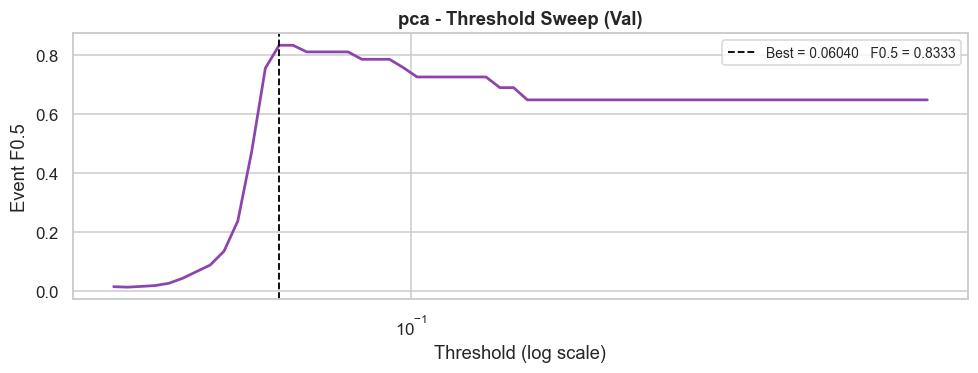

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(sweep['sweep_thresholds'], sweep['sweep_scores'], color='#8e44ad', lw=1.8)
ax.axvline(THRESHOLD, color='black', ls='--', lw=1.2,
           label=f'Best = {THRESHOLD:.5f}   F0.5 = {sweep["score"]:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Threshold (log scale)')
ax.set_ylabel('Event F0.5')
ax.set_title(f'{MODEL_NAME} - Threshold Sweep (Val)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

### Threshold comparison

Evaluate several candidate thresholds side-by-side on val AND test_intern. Use this to pick a threshold by trade-off instead of by auto-tune alone: auto-tune maximises one metric on val, but a nearby threshold might give you better ESA F0.5 or row-level precision on test. Set `MANUAL_THRESHOLD` in the cell above to whichever row you prefer and re-run from there.

In [ ]:
# Compare a grid of thresholds on val + test_intern.
# Defaults: auto-tuned threshold ± a log-spaced fan around it.
thr_auto = sweep['threshold']
THR_GRID = sorted({
    thr_auto * 0.5, thr_auto * 0.75, thr_auto,
    thr_auto * 1.25, thr_auto * 1.5, thr_auto * 2.0,
})

def _row(scores, y_true, thr):
    y_pred = (scores > thr).astype(np.int8)
    m = compute_all_metrics(y_true, y_pred)
    return {
        'threshold'    : thr,
        'Event F0.5'   : m['event_f05'],
        'Event prec'   : m['event_precision'],
        'Event recall' : m['event_recall'],
        'Events hit'   : f"{m['tp_events']}/{m['n_events']}",
        'FP events'    : int(m['fp_pred_events']),
        'ESA F0.5'     : m['esa_f05'],
        'Row F1'       : m['row_f1'],
        'Pos rate'     : float((y_pred == 1).mean()),
    }

rows_val  = [{'split': 'Val',         **_row(scores_val,         y_val,         t)} for t in THR_GRID]
rows_test = [{'split': 'Test intern', **_row(scores_test_intern, y_test_intern, t)} for t in THR_GRID]
df_grid = pd.DataFrame(rows_val + rows_test).set_index(['split', 'threshold'])

# Highlight the auto-tuned row for quick spotting.
def _highlight_auto(row):
    is_auto = np.isclose(row.name[1], thr_auto)
    return ['background-color: #fff3bf' if is_auto else '' for _ in row]

print(f'{MODEL_NAME} — threshold comparison  (auto-tuned = {thr_auto:.6f}, highlighted)')
df_grid.style.apply(_highlight_auto, axis=1).format({
    'threshold'    : '{:.6f}',
    'Event F0.5'   : '{:.4f}',
    'Event prec'   : '{:.4f}',
    'Event recall' : '{:.4f}',
    'ESA F0.5'     : '{:.4f}',
    'Row F1'       : '{:.4f}',
    'Pos rate'     : '{:.2%}',
})


pca — threshold comparison  (auto-tuned = 0.060404, highlighted)


---
## 5 — Score distribution

Histograms of the row-level score, split by ground-truth label. The threshold line shows how cleanly the two populations separate at the currently selected value. A nominal tail that sticks out past the threshold is the source of false-positive events; an anomaly bump left of it is missed events.

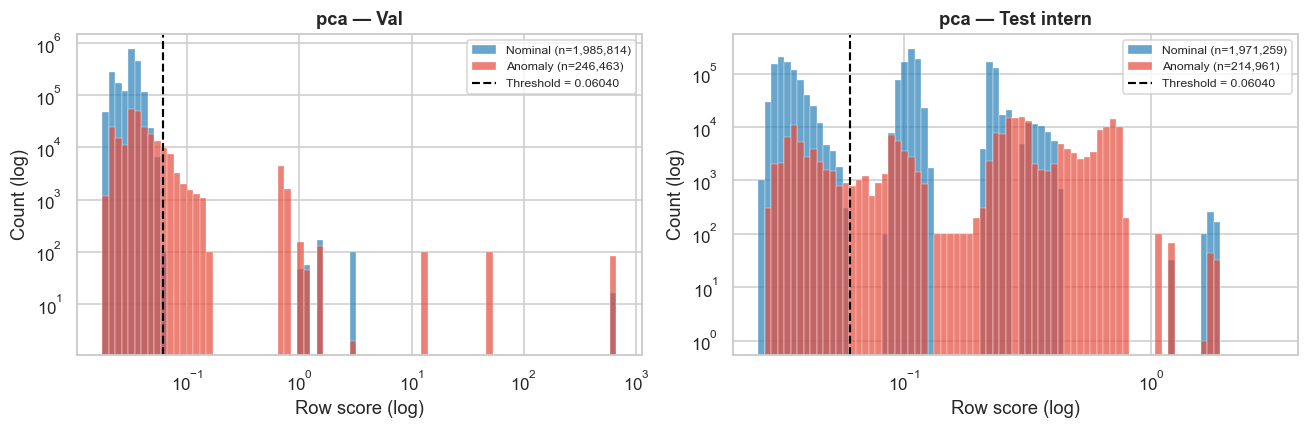

In [ ]:
# log-x histograms — scores are heavy-tailed, linear-x hides the nominal bulk.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (label, scores, y_true) in zip(axes, [
    ('Val',         scores_val,         y_val),
    ('Test intern', scores_test_intern, y_test_intern),
]):
    nom = scores[y_true == 0]
    ano = scores[y_true == 1]
    # log-safe lower bound
    lo = max(min(nom.min(), ano.min() if len(ano) else nom.min()), 1e-8)
    hi = max(nom.max(), ano.max() if len(ano) else nom.max())
    bins = np.logspace(np.log10(lo), np.log10(hi), 80)

    ax.hist(nom, bins=bins, color=NOMINAL_COLOR, alpha=0.7, label=f'Nominal (n={len(nom):,})', edgecolor='white', linewidth=0.3)
    if len(ano):
        ax.hist(ano, bins=bins, color=ANOMALY_COLOR, alpha=0.7, label=f'Anomaly (n={len(ano):,})', edgecolor='white', linewidth=0.3)
    ax.axvline(THRESHOLD, color='black', ls='--', lw=1.4, label=f'Threshold = {THRESHOLD:.5f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Row score (log)')
    ax.set_ylabel('Count (log)')
    ax.set_title(f'{MODEL_NAME} — {label}', fontweight='bold')
    ax.legend(fontsize=8)

fig.tight_layout(); plt.show()


---
## 6 — Metrics

**Top** — the tuning target (`TUNE_METRIC`) at the current threshold on val vs test_intern. This is the number you were just optimising for.

**Below** — the full metric panel split into three families:
- **Event-wise** (tolerates over-flagging, any detected overlap counts the event as a hit). Our headline family.
- **ESA-corrected** (precision × TNR — penalises wide predicted blocks the way Kaggle scores do).
- **Row-level** (no tolerance — what fraction of rows you got exactly right).

A big gap between Event F0.5 and ESA F0.5 / Row F1 signals over-flagging (see NB 14 timeline plots).

In [ ]:
# ── Headline: the tuning target at the current threshold ──────────────────
def _tune_val(scores, y_true, thr, fn):
    return fn(y_true, (scores > thr).astype(np.int8))['f_score']

tune_name = TUNE_METRIC.__name__
tune_val  = _tune_val(scores_val,         y_val,         THRESHOLD, TUNE_METRIC)
tune_test = _tune_val(scores_test_intern, y_test_intern, THRESHOLD, TUNE_METRIC)
print(f'{MODEL_NAME} @ threshold {THRESHOLD:.5f}')
print(f'  >>> TUNE_METRIC = {tune_name}:   val = {tune_val:.4f}   |   test_intern = {tune_test:.4f}  <<<')


# ── Full panel — grouped by family ────────────────────────────────────────
def _panel(scores, y_true, threshold):
    y_pred = (scores > threshold).astype(np.int8)
    m = compute_all_metrics(y_true, y_pred)
    return m, float((y_pred == 1).mean())

m_val,  pos_val  = _panel(scores_val,         y_val,         THRESHOLD)
m_test, pos_test = _panel(scores_test_intern, y_test_intern, THRESHOLD)

# Metric groups — key: (source_key_in_m, display label, format)
GROUPS = {
    'Event-wise (headline)': [
        ('event_f05',            'Event F0.5',           '{:.4f}'),
        ('event_f1',             'Event F1',             '{:.4f}'),
        ('event_f2',             'Event F2',             '{:.4f}'),
        ('event_precision',      'Event precision',      '{:.4f}'),
        ('event_recall',         'Event recall',         '{:.4f}'),
        ('event_detection_rate', 'Event detection rate', '{:.4f}'),
        ('tp_events',            'Events hit',           'int_of_n'),   # special: tp/n
        ('fp_pred_events',       'FP predicted events',  '{:d}'),
    ],
    'ESA-corrected (Kaggle-style)': [
        ('esa_f05',       'ESA F0.5',      '{:.4f}'),
        ('esa_precision', 'ESA precision', '{:.4f}'),
        ('esa_recall',    'ESA recall',    '{:.4f}'),
        ('esa_tnr',       'ESA TNR',       '{:.4f}'),
    ],
    'Row-level (no tolerance)': [
        ('row_f1',        'Row F1',        '{:.4f}'),
        ('row_precision', 'Row precision', '{:.4f}'),
        ('row_recall',    'Row recall',    '{:.4f}'),
        ('__pos_rate',    'Positive rate', '{:.2%}'),
    ],
}

def _fmt_val(key, label, fmt, m, pos_rate):
    if key == '__pos_rate':
        v = pos_rate
    elif fmt == 'int_of_n':
        return f"{int(m['tp_events'])}/{int(m['n_events'])}"
    elif key == 'fp_pred_events':
        v = int(m[key])
    else:
        v = m[key]
    return fmt.format(v)

# Which labels in the panel ARE the tuning metric? (for highlighting)
TUNE_LABEL = {
    'event_f05': 'Event F0.5',
    'event_f1' : 'Event F1',
    'event_f2' : 'Event F2',
    'esa_metric': 'ESA F0.5',
}.get(tune_name, None)

def _render_group(name, rows):
    df = pd.DataFrame(
        [
            {'Metric': lbl,
             'Val':         _fmt_val(key, lbl, fmt, m_val,  pos_val),
             'Test intern': _fmt_val(key, lbl, fmt, m_test, pos_test)}
            for key, lbl, fmt in rows
        ]
    ).set_index('Metric')

    print(f'\n── {name} ' + '─' * max(0, 55 - len(name)))
    if TUNE_LABEL in df.index:
        # mark the tuning-target row
        styled = df.style.apply(
            lambda r: ['background-color: #fff3bf' if r.name == TUNE_LABEL else '' for _ in r],
            axis=1,
        )
        from IPython.display import display
        display(styled)
    else:
        from IPython.display import display
        display(df)

for name, rows in GROUPS.items():
    _render_group(name, rows)


pca @ threshold 0.06040
  >>> TUNE_METRIC = event_f05:   val = 0.8333   |   test_intern = 0.9843  <<<

── Event-wise (headline) ──────────────────────────────────


,Val,Test intern
Metric,,
Event F0.5,0.8333,0.9843
Event F1,0.6667,0.9615
Event F2,0.5556,0.9398
Event precision,1.0000,1.0000
Event recall,0.5000,0.9259
Event detection rate,0.5000,0.9259
Events hit,13/26,25/27
FP predicted events,0,0



── ESA-corrected (Kaggle-style) ───────────────────────────


,Val,Test intern
Metric,,
ESA F0.5,0.8332,0.4736
ESA precision,0.9998,0.4220
ESA recall,0.5000,0.9259
ESA TNR,0.9998,0.4220



── Row-level (no tolerance) ───────────────────────────────


,Val,Test intern
Metric,,
Row F1,0.2181,0.2281
Row precision,0.9874,0.1327
Row recall,0.1226,0.8110
Positive rate,1.37%,60.09%


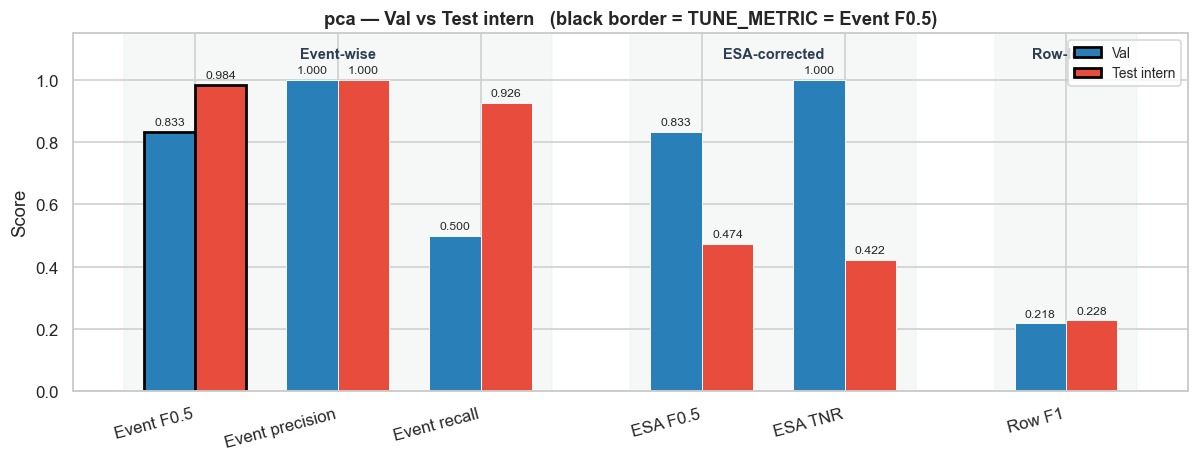

In [ ]:
# Bar chart grouped by family. The TUNE_METRIC bars are framed in black.
BAR_GROUPS = [
    ('Event-wise',    ['Event F0.5', 'Event precision', 'Event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['Row F1']),
]

# Pull values via the same m_val / m_test dicts used above.
LABEL_TO_KEY = {
    'Event F0.5'     : 'event_f05',
    'Event precision': 'event_precision',
    'Event recall'   : 'event_recall',
    'ESA F0.5'       : 'esa_f05',
    'ESA TNR'        : 'esa_tnr',
    'Row F1'         : 'row_f1',
}

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.36, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in labels:
        xs.append(cursor)
        xticks.append(cursor)
        xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap  # gap between groups

xs = np.asarray(xs)
vals_val  = [m_val [LABEL_TO_KEY[l]] for l in xlabels]
vals_test = [m_test[LABEL_TO_KEY[l]] for l in xlabels]

# Framed edge for the tuning metric
def _edges(labels, tune_label):
    return ['black' if l == tune_label else 'white' for l in labels]
def _lw(labels, tune_label):
    return [1.8 if l == tune_label else 0.6 for l in labels]

b1 = ax.bar(xs - w/2, vals_val,  w, label='Val',         color=NOMINAL_COLOR,
            edgecolor=_edges(xlabels, TUNE_LABEL), linewidth=_lw(xlabels, TUNE_LABEL))
b2 = ax.bar(xs + w/2, vals_test, w, label='Test intern', color=ANOMALY_COLOR,
            edgecolor=_edges(xlabels, TUNE_LABEL), linewidth=_lw(xlabels, TUNE_LABEL))
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)

# Group bands + labels
for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo + xhi) / 2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
title = f'{MODEL_NAME} — Val vs Test intern'
if TUNE_LABEL:
    title += f'   (black border = TUNE_METRIC = {TUNE_LABEL})'
ax.set_title(title, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout(); plt.show()


---
## 7 - Validation Timeline

Where does the model flag anomalies in the val and test_intern timelines?


In [ ]:
from sentinel.ml_logic.viz import plot_timeline

# showcase-Darstellung: log-y
_ = plot_timeline(scores_val, y_val, THRESHOLD,
              f'{MODEL_NAME} - Val Timeline (log-y)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(scores_test_intern, y_test_intern, THRESHOLD,
              f'{MODEL_NAME} - Test intern Timeline (log-y)', log_y=True)
plt.show(); plt.close()

# # Test mit absoluten Row-Indizes aus Original-Dataset
# _ = plot_timeline(scores_test_intern, y_test_intern, THRESHOLD,
#               f'{MODEL_NAME} - Test intern Timeline',
#               log_y=True,
#               index=df_original.index.values[test_start:test_end])
# plt.show(); plt.close()

NameError: name 'scores_val' is not defined

---
## 8 - Per-Event Detection


In [ ]:
def event_table(scores, y_true, threshold, label):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    rows = []
    for seg in segments:
        n_det = int(y_pred[seg['start']:seg['end']+1].sum())
        rows.append({
            'start'      : seg['start'],
            'end'        : seg['end'],
            'length'     : seg['length'],
            'detected'   : n_det > 0,
            'hit_rate'   : round(n_det / seg['length'], 3),
        })
    df = pd.DataFrame(rows)
    n_det   = int(df['detected'].sum())
    n_miss  = len(df) - n_det
    print(f'{label}: {n_det}/{len(df)} events detected  ({n_miss} missed)')
    return df

df_val  = event_table(scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} Val')
df_test = event_table(scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} Test intern')

pca Val: 13/26 events detected  (13 missed)
pca Test intern: 25/27 events detected  (2 missed)


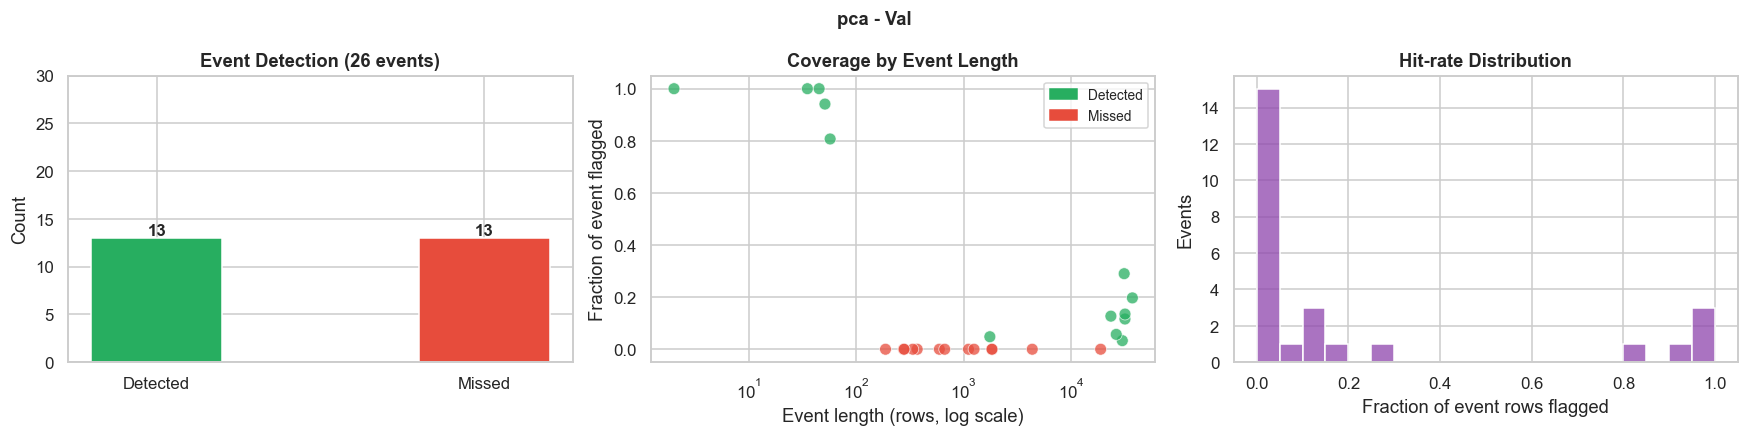

Missed events:
  start     end  length
  97133   97726     594
 399395  399763     369
 548497  552855    4359
 565099  584013   18915
 819541  819876     336
1337362 1339200    1839
1342475 1344310    1836
1556161 1556436     276
1912322 1912508     187
1912819 1913928    1110
1917562 1918227     666
2009869 2010147     279
2069274 2070523    1250


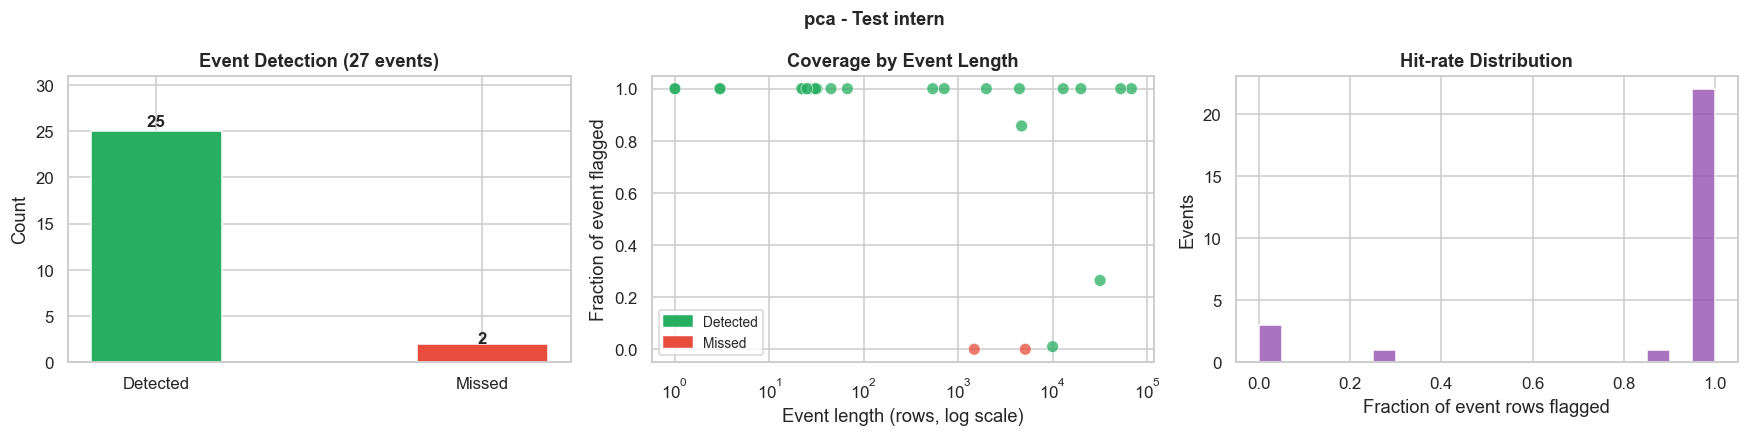

Missed events:
 start    end  length
400398 401877    1480
643518 648653    5136


In [ ]:
def plot_event_analysis(df, scores, y_true, threshold, title):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    n_det  = int(df['detected'].sum())
    n_miss = len(df) - n_det
    n_ev   = len(df)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Detected vs missed bar
    ax = axes[0]
    counts = pd.Series({'Detected': n_det, 'Missed': n_miss})
    colors = ['#27ae60', ANOMALY_COLOR]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.4)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Event Detection ({n_ev} events)', fontweight='bold')
    ax.set_ylabel('Count'); ax.set_ylim(0, n_ev + 4)

    # Hit rate by event length
    ax2 = axes[1]
    colors_pt = [('#27ae60' if d else ANOMALY_COLOR) for d in df['detected']]
    ax2.scatter(df['length'], df['hit_rate'], c=colors_pt, s=60, alpha=0.75,
                edgecolors='white', lw=0.5)
    ax2.set_xscale('log')
    ax2.set_xlabel('Event length (rows, log scale)')
    ax2.set_ylabel('Fraction of event flagged')
    ax2.set_title('Coverage by Event Length', fontweight='bold')
    ax2.set_ylim(-0.05, 1.05)
    handles = [mpatches.Patch(color='#27ae60', label='Detected'),
               mpatches.Patch(color=ANOMALY_COLOR, label='Missed')]
    ax2.legend(handles=handles, fontsize=9)

    # Hit-rate distribution
    ax3 = axes[2]
    sns.histplot(df['hit_rate'], bins=20, ax=ax3, color='#8e44ad', edgecolor='white')
    ax3.set_xlabel('Fraction of event rows flagged')
    ax3.set_ylabel('Events')
    ax3.set_title('Hit-rate Distribution', fontweight='bold')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()

    if n_miss:
        print('Missed events:')
        print(df[~df['detected']][['start','end','length']].to_string(index=False))

plot_event_analysis(df_val,  scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} - Val')
plot_event_analysis(df_test, scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} - Test intern')

---
## 9 — Confusion Matrix + Top Channels

Row-level confusion matrix (counts + % of all rows) and the top-k channels
ranked by mean reconstruction MSE *inside true-anomaly windows* — matches the
diagnostic from NB 15. Anomalies usually concentrate in a handful of channels;
this tells you which ones actually drove the decision.

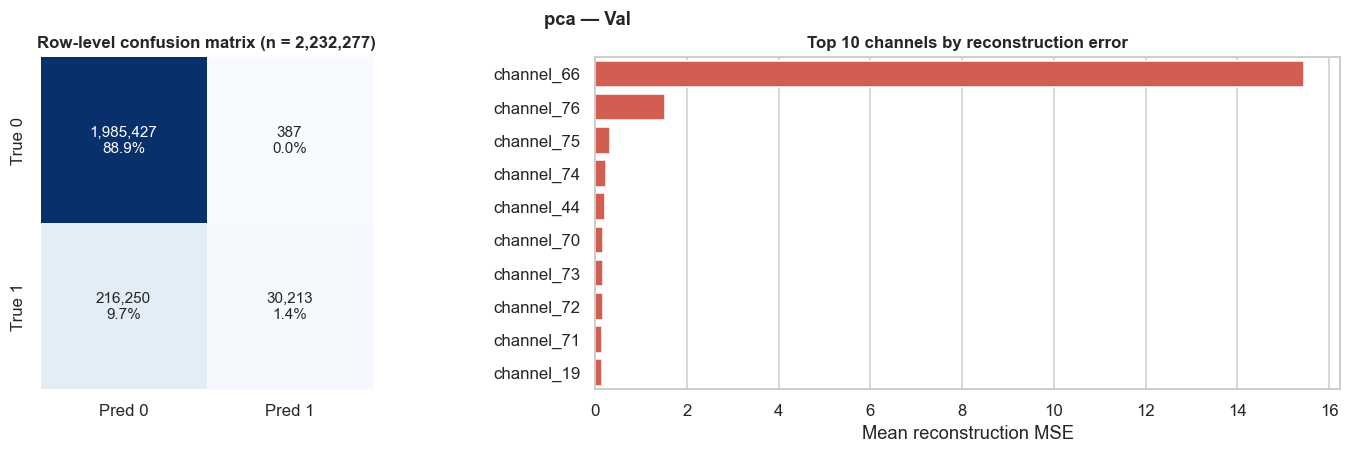

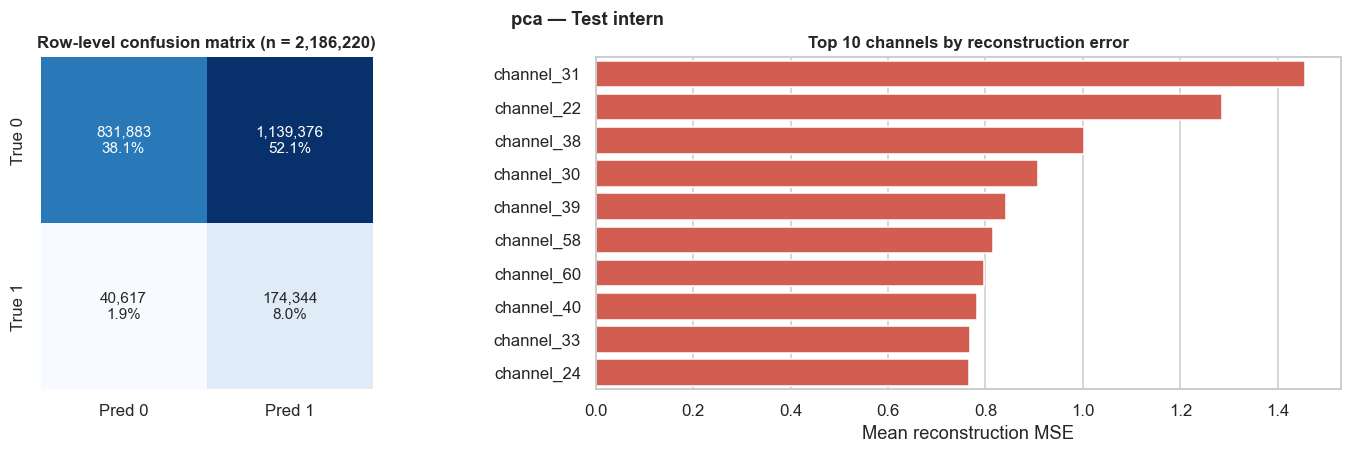

In [ ]:
# Per-channel MSE inside true-anomaly windows (signal-heavy rule, like NB 15).
# Fallback to the overall per-channel MSE if no anomaly windows overlap.
def per_channel_mse_in_anomaly_windows(rep, y_true, win):
    wcm     = rep['window_channel_mse']        # (n_win, n_feat)
    n_win   = wcm.shape[0]
    if n_win == 0:
        return rep['per_channel_mse']
    # window is anomalous if ANY row in its non-overlapping slice is anomalous
    y_by_win = y_true[: n_win * win].reshape(n_win, win).any(axis=1)
    if not y_by_win.any():
        return rep['per_channel_mse']
    return wcm[y_by_win].mean(axis=0)

for label, rep, y_t, scores in [
    ('Val',         rep_val,  y_val,         scores_val),
    ('Test intern', rep_test, y_test_intern, scores_test_intern),
]:
    y_pred = (scores > THRESHOLD).astype(np.int8)
    per_ch_anom = per_channel_mse_in_anomaly_windows(rep, y_t, WIN)
    fig = plot_confusion_and_channel_errors(
        y_true         = y_t,
        y_pred         = y_pred,
        per_channel_mse= per_ch_anom,
        channel_names  = FEATURES,
        top_k          = 10,
    )
    fig.suptitle(f'{MODEL_NAME} — {label}', fontsize=12, fontweight='bold', y=1.02)
    plt.show(); plt.close(fig)

---
## 10 - Bootstrap Confidence Interval
**TAKES VERY LONG**


In [ ]:
y_pred_val  = (scores_val > THRESHOLD).astype(np.int8)
y_pred_test = (scores_test_intern > THRESHOLD).astype(np.int8)

print('Bootstrap CI (200 iterations, event-block) ...')
ci_val  = bootstrap_f05_ci(y_val,         y_pred_val,  n_boot=200)
ci_test = bootstrap_f05_ci(y_test_intern, y_pred_test, n_boot=200)

for label, ci in [('Val', ci_val), ('Test intern', ci_test)]:
    print(f'  {label:<12} F0.5 = {ci["mean"]:.4f} ± {ci["std"]:.4f}'
          f'  95% CI [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap CI (200 iterations, event-block) ...
  Val          F0.5 = 0.6590 ± 0.1107  95% CI [0.4542, 0.8475]
  Test intern  F0.5 = 0.8053 ± 0.0770  95% CI [0.6730, 0.9501]


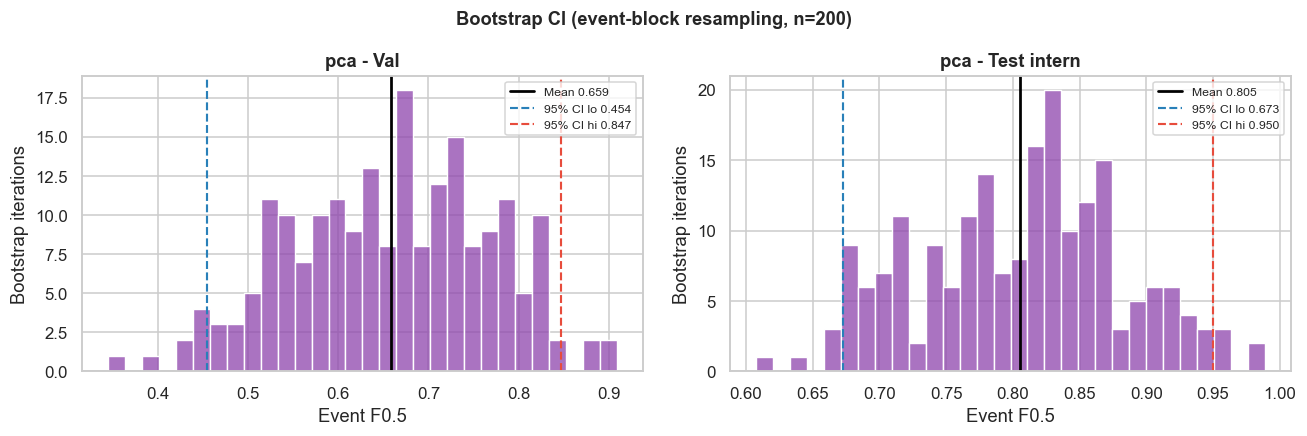

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, ci) in zip(axes, [('Val', ci_val), ('Test intern', ci_test)]):
    sns.histplot(ci['all_scores'], bins=30, ax=ax, color='#8e44ad', edgecolor='white')
    ax.axvline(ci['mean'],    color='black',        lw=1.8, ls='-',  label=f'Mean {ci["mean"]:.3f}')
    ax.axvline(ci['ci_lo_95'], color=NOMINAL_COLOR, lw=1.4, ls='--', label=f'95% CI lo {ci["ci_lo_95"]:.3f}')
    ax.axvline(ci['ci_hi_95'], color=ANOMALY_COLOR, lw=1.4, ls='--', label=f'95% CI hi {ci["ci_hi_95"]:.3f}')
    ax.set_xlabel('Event F0.5')
    ax.set_ylabel('Bootstrap iterations')
    ax.set_title(f'{MODEL_NAME} - {label}', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Bootstrap CI (event-block resampling, n=200)', fontsize=12, fontweight='bold')
fig.tight_layout(); plt.show()

---
## 11 — Save scores & build submission 

Persist the row-level scores for later re-use (e.g. ensemble averaging, drift plots) and/or build a Kaggle submission parquet by scoring `test.parquet` with the currently loaded model + tuned threshold. Both blocks are off by default — uncomment what you need.

In [ ]:
# # ─── Save row-level scores + threshold ───────────────────────────────────
# # Timestamped so re-runs don't overwrite earlier artefacts (per project convention).
# from datetime import datetime
# stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# out_dir = PROCESSED_DIR / 'model_scores'
# out_dir.mkdir(parents=True, exist_ok=True)
# stem = MODEL_PATH.stem
#
# np.save(out_dir / f'{stem}_val_scores_{stamp}.npy',         scores_val)
# np.save(out_dir / f'{stem}_test_intern_scores_{stamp}.npy', scores_test_intern)
# with open(out_dir / f'{stem}_threshold_{stamp}.json', 'w') as f:
#     json.dump({
#         'model'          : MODEL_NAME,
#         'model_file'     : MODEL_PATH.name,
#         'threshold'      : float(THRESHOLD),
#         'topk'           : TOPK,
#         'use_detrend'    : USE_DETREND,
#         'detrend_mode'   : DETREND_MODE,
#         'detrend_window' : DETREND_WINDOW,
#         'win'            : WIN,
#     }, f, indent=2)
# print(f'saved scores + config to {out_dir}  (stamp {stamp})')


In [ ]:
# # ─── Build Kaggle submission on data/raw/test.parquet ────────────────────
# # Uses the model + threshold that are currently loaded in this notebook.
# from sentinel.ml_logic.data       import load_test
# from sentinel.ml_logic.preprocessor import run_preprocessing_kaggle  # or scale manually
# from kaggle.submission            import make_submission, submission_summary, default_submission_path
#
# df_test_kaggle = load_test()
# test_ids       = df_test_kaggle['id'].values
# # Scale with the SAME scaler that produced val_scaled / test_intern_scaled.
# # If you don't have it in memory, load it from models/scaler.pkl.
# with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)
# X_kaggle = scaler.transform(df_test_kaggle[FEATURES].values.astype(np.float32)).astype(np.float32)
#
# scores_kaggle = score_windows(model, X_kaggle, win=WIN, topk=TOPK)
# if USE_DETREND:
#     scores_kaggle = detrend_scores(scores_kaggle, window=DETREND_WINDOW, mode=DETREND_MODE)
# labels_kaggle = (scores_kaggle > THRESHOLD).astype(np.uint8)
#
# stamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
# out_path = default_submission_path(f'{MODEL_PATH.stem}_{stamp}')
# sub_df   = make_submission(
#     predictions = labels_kaggle,
#     test_ids    = test_ids,
#     out_path    = out_path,
#     validate_schema = True,
# )
# print('submission written →', out_path)
# print(submission_summary(sub_df))